# Mahalanobis OOD Detection on GTSRB

MobileNetV2 trained on GTSRB. Per-layer Mahalanobis distance scoring against multiple out-of-domain sources, evaluated by AUROC, TNR@95% TPR and detection accuracy.


## 1. Configuration


In [ ]:
import os, sys, time, json, random, urllib.request, zipfile
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from torchvision.datasets import GTSRB
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights
from PIL import Image
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import pandas as pd

import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

# ---- paths
DATA_DIR = "data"
CKPT_DIR = "checkpoints"
CACHE_DIR = "cache"
CKPT_PATH = os.path.join(CKPT_DIR, "mobilenetv2_gtsrb_best.pth")
for d in (DATA_DIR, CKPT_DIR, CACHE_DIR):
    os.makedirs(d, exist_ok=True)

# ---- training control
TRAIN_FROM_SCRATCH = False  # set True to force a retrain even if a checkpoint exists
M_DISTANCE_POOLING = "softmax"  # "softmax" or "avg" (default avg) --- IGNORE ---
EPOCHS = 8
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
SEED = 0

# ---- data + model
NUM_CLASSES = 43    # GTSRB has 43 sign classes
IMG_SIZE = 224  # MobileNetV2's native ImageNet input size
NORM_MEAN = [0.485, 0.456, 0.406]   # standard ImageNet normalization (must match pretraining)
NORM_STD = [0.229, 0.224, 0.225]
LAYERS = list(range(19))    # All 19 blocks in MobileNetV2's `model.features` (stem + 17 inverted residuals + final 1x1)
LAYER_NAMES = [f"block{i}" for i in LAYERS]

# Per-layer spatial pool size before flatten. 1 = global average pool (collapse HxW to 1x1).
# Larger k preserves more spatial info, useful for early layers where channels are few.
POOL_SIZES = {f"block{i}": (4 if i <= 6 else 2 if i <= 13 else 1) for i in LAYERS}

# ---- OOD eval split sizes
# Held-out test size per side; follows Lee et al.'s split. Each OOD source caps at its own dataset size.
N_ID_VAL, N_ID_TEST = 1000, 5000
N_OOD_TEST = 5000

# ---- determinism
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = (torch.device("mps")  if torch.backends.mps.is_available()
          else torch.device("cuda") if torch.cuda.is_available()
          else torch.device("cpu"))
print("device:", DEVICE)
print("checkpoint exists:", os.path.exists(CKPT_PATH))

device: cpu
checkpoint exists: True


## 2. In-Domain (GTSRB)

Full pipeline for the in-distribution data: dataset, transforms, model, training, evaluation, feature extraction, and Gaussian fit.

### Data

Downloads GTSRB into `./data/`.


In [36]:
print("--> GTSRB train"); GTSRB(root=DATA_DIR, split="train", download=True)
print("--> GTSRB test");  GTSRB(root=DATA_DIR, split="test",  download=True)
print("data ready")

--> GTSRB train


100%|██████████| 187490228/187490228 [00:09<00:00, 20349274.90it/s]


Extracting data\gtsrb\GTSRB-Training_fixed.zip to data\gtsrb
--> GTSRB test


100%|██████████| 88978620/88978620 [00:02<00:00, 30774269.46it/s]


Extracting data\gtsrb\GTSRB_Final_Test_Images.zip to data\gtsrb


100%|██████████| 99620/99620 [00:00<00:00, 2107220.63it/s]

Extracting data\gtsrb\GTSRB_Final_Test_GT.zip to data\gtsrb
data ready


### Transforms

Mild augmentation for training, deterministic transform for eval.


In [37]:
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomAffine(degrees=10, translate=(0.05, 0.05),
                            scale=(0.9, 1.1), shear=5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD),
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD),
])

### Model

MobileNetV2 with the final linear replaced by a 43-way head. The backbone is initialized from ImageNet-pretrained weights.

In [38]:
def build_model(pretrained=True):
    weights = MobileNet_V2_Weights.IMAGENET1K_V1 if pretrained else None
    m = mobilenet_v2(weights=weights)
    m.classifier[1] = nn.Linear(1280, NUM_CLASSES)
    return m

### Training

Skipped if `TRAIN_FROM_SCRATCH=False` and a checkpoint exists. Stratified 90/10 split, AdamW + cosine LR, 8 epochs, batch 64, save best by val accuracy. Per-epoch history is stored inside the checkpoint.


In [5]:
def train_model():
    full_train_aug = GTSRB(root=DATA_DIR, split="train", transform=train_tf, download=False)
    full_train_eval = GTSRB(root=DATA_DIR, split="train", transform=eval_tf,  download=False)
    labels = np.array([lbl for _, lbl in full_train_aug._samples])
    rng = np.random.default_rng(SEED)
    train_idx, val_idx = [], []
    for c in np.unique(labels):
        idx = np.where(labels == c)[0]; rng.shuffle(idx)
        n_val = max(1, int(round(0.1 * len(idx))))
        val_idx.extend(idx[:n_val].tolist()); train_idx.extend(idx[n_val:].tolist())
    train_idx = np.array(train_idx); val_idx = np.array(val_idx)
    print(f"train={len(train_idx)}  val={len(val_idx)}  classes={len(np.unique(labels))}",
          flush=True)

    train_ds = Subset(full_train_aug,  train_idx)
    val_ds = Subset(full_train_eval, val_idx)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
    val_loader = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    model = build_model(pretrained=True).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    criterion = nn.CrossEntropyLoss()

    @torch.no_grad()
    def evaluate(loader):
        model.eval()
        correct = total = 0; loss_sum = 0.0
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            loss_sum += criterion(out, y).item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)
        return correct / total, loss_sum / total

    history, best_val = [], 0.0
    for epoch in range(EPOCHS):
        model.train()
        t0 = time.time()
        running_loss = running_correct = running_total = 0
        for i, (x, y) in enumerate(train_loader):
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            out = model(x); loss = criterion(out, y)
            loss.backward(); optimizer.step()
            running_loss    += loss.item() * x.size(0)
            running_correct += (out.argmax(1) == y).sum().item()
            running_total   += y.size(0)
            if (i + 1) % 10 == 0 or i == 0:
                print(f"  ep{epoch+1} step {i+1}/{len(train_loader)} "
                      f"loss={running_loss/running_total:.4f} "
                      f"acc={running_correct/running_total:.4f}", flush=True)
        scheduler.step()
        train_loss = running_loss / running_total
        train_acc = running_correct / running_total
        val_acc, val_loss = evaluate(val_loader)
        print(f"epoch {epoch+1}/{EPOCHS}  train_acc={train_acc:.4f}  "
              f"val_acc={val_acc:.4f}  val_loss={val_loss:.4f}  "
              f"lr={scheduler.get_last_lr()[0]:.2e}  ({time.time()-t0:.1f}s)",
              flush=True)
        history.append({"epoch": epoch+1, "train_loss": train_loss,
                        "train_acc": train_acc, "val_loss": val_loss,
                        "val_acc": val_acc})
        if val_acc > best_val:
            best_val = val_acc
            torch.save({"model_state_dict": model.state_dict(),
                        "epoch": epoch+1, "val_acc": val_acc,
                        "best_val_acc": val_acc,
                        "train_idx": train_idx.tolist(),
                        "val_idx":   val_idx.tolist(),
                        "history": list(history)}, CKPT_PATH)
            print(f"  ↳ saved best ({val_acc:.4f}) to {CKPT_PATH}", flush=True)
    print(f"\nDONE  best_val_acc={best_val:.4f}")

if TRAIN_FROM_SCRATCH or not os.path.exists(CKPT_PATH):
    train_model()
else:
    print(f"checkpoint found at {CKPT_PATH} , skipping training")

checkpoint found at checkpoints/mobilenetv2_gtsrb_best.pth , skipping training


### Loaded model


In [39]:
ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=True)
model = build_model(pretrained=False)
model.load_state_dict(ckpt["model_state_dict"])
model = model.to(DEVICE).eval()

train_idx = np.asarray(ckpt["train_idx"])
val_idx = np.asarray(ckpt["val_idx"])
print(f"loaded checkpoint  epoch={ckpt['epoch']}  best_val_acc={ckpt['val_acc']:.4f}")
print(f"split sizes: train={len(train_idx)}  val={len(val_idx)}")
train_idx = train_idx[train_idx < len(gtsrb_train_eval)]
val_idx   = val_idx[val_idx < len(gtsrb_train_eval)]

loaded checkpoint  epoch=6  best_val_acc=0.9996
split sizes: train=23976  val=2664


In [20]:
print(model)

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

### Training curves

Train and val loss/accuracy per epoch from the checkpoint history.


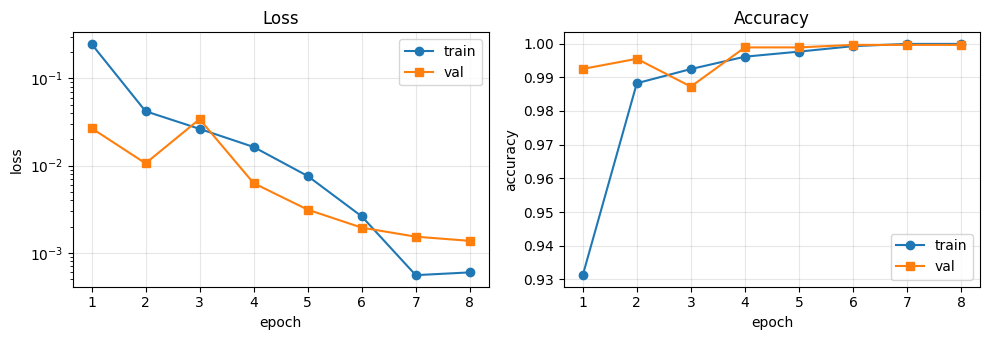

In [40]:
hist = ckpt.get("history")
if hist:
    epochs = [h["epoch"] for h in hist]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))
    ax1.plot(epochs, [h["train_loss"] for h in hist], "-o", label="train")
    ax1.plot(epochs, [h["val_loss"]   for h in hist], "-s", label="val")
    ax1.set_xlabel("epoch"); ax1.set_ylabel("loss"); ax1.set_yscale("log")
    ax1.set_title("Loss"); ax1.legend(); ax1.grid(alpha=0.3)
    ax2.plot(epochs, [h["train_acc"] for h in hist], "-o", label="train")
    ax2.plot(epochs, [h["val_acc"]   for h in hist], "-s", label="val")
    ax2.set_xlabel("epoch"); ax2.set_ylabel("accuracy")
    ax2.set_title("Accuracy"); ax2.legend(); ax2.grid(alpha=0.3)
    plt.tight_layout(); plt.show()
else:
    print("no history in checkpoint (older format)")

### Accuracy on held-out val and on the official test set


In [41]:
gtsrb_train_eval = GTSRB(root=DATA_DIR, split="train", transform=eval_tf)
gtsrb_test       = GTSRB(root=DATA_DIR, split="test",  transform=eval_tf)

@torch.no_grad()
def accuracy(loader):
    correct = total = 0
    for x, y in loader:
        x = x.to(DEVICE)
        correct += (model(x).argmax(1).cpu() == y).sum().item()
        total += y.size(0)
    return correct / total

# Val acc was recorded during training and stored in the checkpoint, no recompute needed.
modelval_acc = ckpt["val_acc"]

# Cache test accuracy: deterministic, so we only ever compute it once.
test_acc_path = os.path.join(CACHE_DIR, "gtsrb_test_acc.json")
if os.path.exists(test_acc_path):
    test_acc = json.load(open(test_acc_path))["test_acc"]
else:
    test_acc = accuracy(DataLoader(gtsrb_test, batch_size=128, num_workers=0))
    with open(test_acc_path, "w") as f:
        json.dump({"test_acc": test_acc}, f)

print(f"GTSRB model-val top-1 (random 10% of train, leaky): {modelval_acc:.4f}")
print(f"GTSRB official test  top-1 (different signs entirely): {test_acc:.4f}")

GTSRB model-val top-1 (random 10% of train, leaky): 0.9996
GTSRB official test  top-1 (different signs entirely): 0.9925


### Feature extraction

Hook all 19 MobileNetV2 blocks, pool the spatial maps (per-layer pool size
from `POOL_SIZES`), cache to `./cache/`.


In [ ]:
class FeatureHooks:
    """Attach forward hooks; collect pooled features (B,C) per named layer."""

    def __init__(self, model, layer_indices, pooling="avg"):
        """
        pooling:
            "avg"     -> average pooling
            "softmax" -> softmax-weighted spatial pooling
        """
        self.layer_indices = layer_indices
        self.pooling = pooling
        self.features = {}
        self._handles = []

        for idx in layer_indices:
            name = f"block{idx}"
            self._handles.append(
                model.features[idx].register_forward_hook(self._hook(name))
            )

    def _hook(self, name):
        def fn(_, __, out):

            if out.dim() == 4:
                k = POOL_SIZES.get(name, 1)

                # -----------------------------------
                # STANDARD AVG POOLING
                # -----------------------------------
                if self.pooling == "avg":

                    if k <= 1:
                        out = out.mean(dim=(2, 3))
                    else:
                        out = F.adaptive_avg_pool2d(out, k).flatten(1)

                # -----------------------------------
                # SOFTMAX-WEIGHTED POOLING
                # -----------------------------------
                elif self.pooling == "softmax":

                    B, C, H, W = out.shape

                    # Flatten spatial dimensions
                    spatial = out.view(B, C, -1)  # (B,C,H*W)

                    # Softmax over spatial positions
                    weights = F.softmax(spatial, dim=-1)

                    # Weighted sum
                    out = (spatial * weights).sum(dim=-1)  # (B,C)

                else:
                    raise ValueError(f"Unknown pooling mode: {self.pooling}")

            self.features[name] = out

        return fn

    def remove(self):
        for h in self._handles:
            h.remove()

hooks = FeatureHooks(model, LAYERS, pooling= M_DISTANCE_POOLING)

def loader(ds, batch=128):
    return DataLoader(ds, batch_size=batch, shuffle=False, num_workers=0)

@torch.no_grad()
def extract(ds, also_logits=False, labels_too=False):
    feats = {n: [] for n in LAYER_NAMES}
    logits, labels = [], []
    for batch in loader(ds):
        x, y = batch
        x = x.to(DEVICE)
        out = model(x)
        for n in LAYER_NAMES:
            feats[n].append(hooks.features[n].detach().cpu().numpy())
        if also_logits: logits.append(out.detach().cpu().numpy())
        if labels_too: labels.append(np.asarray(y))
    feats = {k: np.concatenate(v, 0) for k, v in feats.items()}
    out = {"features": feats}
    if also_logits: out["logits"] = np.concatenate(logits, 0)
    if labels_too:  out["labels"] = np.concatenate(labels, 0)
    return out

def extract_cached(name, ds, also_logits=False, labels_too=False):
    path = os.path.join(CACHE_DIR, f"{name}.npz")
    if os.path.exists(path):
        d = np.load(path, allow_pickle=True)
        out = {"features": {k.replace("feat_", ""): d[k] for k in d.files if k.startswith("feat_")}}
        if "logits" in d.files: out["logits"] = d["logits"]
        if "labels" in d.files: out["labels"] = d["labels"]
        print(f"  load  {name}.npz")
        return out
    print(f"  extract {name} ({len(ds)} samples)", flush=True)
    t0 = time.time()
    out = extract(ds, also_logits=also_logits, labels_too=labels_too)
    save = {f"feat_{k}": v for k, v in out["features"].items()}
    if "logits" in out: save["logits"] = out["logits"]
    if "labels" in out: save["labels"] = out["labels"]
    np.savez_compressed(path, **save)
    print(f"  done in {time.time()-t0:.1f}s")
    return out

In [43]:
gtsrb_fit_ds = Subset(gtsrb_train_eval, train_idx)

rng = np.random.default_rng(1)
perm_id = rng.permutation(len(gtsrb_test))[:N_ID_VAL + N_ID_TEST]
id_test_ds = Subset(gtsrb_test, perm_id[N_ID_VAL:])

print("extracting features ...")
fit_out     = extract_cached("fit",     gtsrb_fit_ds, labels_too=True)
id_test_out = extract_cached("id_test", id_test_ds,   also_logits=True, labels_too=True)

print("\nlayer dims:")
for n in LAYER_NAMES:
    print(f"  {n}: dim={fit_out['features'][n].shape[1]}  "
          f"N_fit={fit_out['features'][n].shape[0]}")

extracting features ...
  extract fit (23391 samples)


  done in 1205.4s
  extract id_test (5000 samples)
  done in 264.6s

layer dims:
  block0: dim=32  N_fit=23391
  block1: dim=16  N_fit=23391
  block2: dim=24  N_fit=23391
  block3: dim=24  N_fit=23391
  block4: dim=32  N_fit=23391
  block5: dim=32  N_fit=23391
  block6: dim=32  N_fit=23391
  block7: dim=64  N_fit=23391
  block8: dim=64  N_fit=23391
  block9: dim=64  N_fit=23391
  block10: dim=64  N_fit=23391
  block11: dim=96  N_fit=23391
  block12: dim=96  N_fit=23391
  block13: dim=96  N_fit=23391
  block14: dim=160  N_fit=23391
  block15: dim=160  N_fit=23391
  block16: dim=160  N_fit=23391
  block17: dim=320  N_fit=23391
  block18: dim=1280  N_fit=23391


### Per-class Gaussians (tied covariance)

Per-class mean plus one shared covariance, matching Eq. 1 of the report.


In [44]:
def fit_gaussian(feats, labels, num_classes, shrink=0.1):
    """Per-class means and a single tied covariance (Eq. 1 of the report)
    with Ledoit-Wolf-style shrinkage for numerical conditioning at high-D layers."""
    feats = np.asarray(feats, dtype=np.float64)
    D = feats.shape[1]
    means = np.zeros((num_classes, D))
    centered = []
    for c in range(num_classes):
        m = feats[labels == c]
        if len(m) == 0: continue
        mu = m.mean(axis=0); means[c] = mu
        centered.append(m - mu)
    centered = np.concatenate(centered, axis=0)
    cov = (centered.T @ centered) / centered.shape[0]
    target = (np.trace(cov) / D) * np.eye(D)
    cov = (1 - shrink) * cov + shrink * target
    return means.astype(np.float32), np.linalg.inv(cov).astype(np.float32)

gaussians = {}
fit_labels = fit_out["labels"]
for n in LAYER_NAMES:
    means, prec = fit_gaussian(fit_out["features"][n], fit_labels, NUM_CLASSES)
    gaussians[n] = (means, prec)
    print(f"  {n}: means {means.shape}  precision {prec.shape}")

  block0: means (43, 32)  precision (32, 32)
  block1: means (43, 16)  precision (16, 16)
  block2: means (43, 24)  precision (24, 24)
  block3: means (43, 24)  precision (24, 24)
  block4: means (43, 32)  precision (32, 32)
  block5: means (43, 32)  precision (32, 32)
  block6: means (43, 32)  precision (32, 32)
  block7: means (43, 64)  precision (64, 64)
  block8: means (43, 64)  precision (64, 64)
  block9: means (43, 64)  precision (64, 64)
  block10: means (43, 64)  precision (64, 64)
  block11: means (43, 96)  precision (96, 96)
  block12: means (43, 96)  precision (96, 96)
  block13: means (43, 96)  precision (96, 96)
  block14: means (43, 160)  precision (160, 160)
  block15: means (43, 160)  precision (160, 160)
  block16: means (43, 160)  precision (160, 160)
  block17: means (43, 320)  precision (320, 320)
  block18: means (43, 1280)  precision (1280, 1280)


## 3. Out-of-Domain Analysis

All OOD evaluations below share the same machinery: per-layer Mahalanobis
scoring against the fitted Gaussians, the same ID test split, the same
metrics. Helpers are defined once in the next cell; every OOD source
calls `analyze_ood_source(...)`. Adding a new source is one cell.

Mahalanobis score:

$$
\text{score}(x) \;=\; \min_{c}\; \bigl(f(x) - \hat{\mu}_c\bigr)^{\!\top}\, \hat{\Sigma}^{-1}\, \bigl(f(x) - \hat{\mu}_c\bigr)
$$

Lower means more in-distribution. Same as Lee et al. Eq. 2 (and Eq. 2 in
the report), with the outer minus sign dropped.


In [45]:
# --- Shared scoring helpers (used for every OOD source below) ---

def mahalanobis_min(feats, means, precision):
    feats = np.asarray(feats, dtype=np.float64)
    means = np.asarray(means, dtype=np.float64)
    P = np.asarray(precision, dtype=np.float64)
    Px = feats @ P
    Pmu = means @ P
    quad_x = np.einsum("nd,nd->n", Px, feats)
    quad_mu = np.einsum("cd,cd->c", Pmu, means)
    cross = Px @ means.T
    return (quad_x[:, None] + quad_mu[None, :] - 2.0 * cross).min(axis=1)

def metric_set(scores_id, scores_ood, higher_is_more_id=True):
    s_id = -scores_id if higher_is_more_id else scores_id
    s_ood = -scores_ood if higher_is_more_id else scores_ood
    y = np.concatenate([np.zeros_like(s_id), np.ones_like(s_ood)])
    s = np.concatenate([s_id, s_ood])
    auroc = roc_auc_score(y, s)
    thr = np.quantile(s_id, 0.95)
    tnr95 = float((s_ood > thr).mean())
    grid = np.quantile(s, np.linspace(0, 1, 1001))
    best = 0.0
    for t in grid:
        best = max(best, 0.5 * ((s_ood >= t).mean() + (s_id < t).mean()))
    return {"auroc": float(auroc), "tnr@95": tnr95, "det_acc": float(best)}

def score_layer(n, feats):
    means, prec = gaussians[n]
    return mahalanobis_min(feats, means, prec)

class OODWrapper(Dataset):
    """Wrap any (image, label) dataset to return (image, 0). Optional subsampling."""
    def __init__(self, base, n=None, seed=0):
        if n is None or n >= len(base):
            self.idx = np.arange(len(base))
        else:
            rng = np.random.default_rng(seed)
            self.idx = rng.permutation(len(base))[:n]
        self.base = base
    def __len__(self): return len(self.idx)
    def __getitem__(self, i):
        x, _ = self.base[int(self.idx[i])]
        return x, 0

def evaluate_ood_source(ood_ds, name):
    """Per-layer Mahalanobis AUROC for any OOD dataset. Caches features under
    `cache/ood_test_{name}.npz`. Returns dict with per_layer, md_ood, best_layer."""
    ood_out = extract_cached(f"ood_test_{name}", ood_ds, also_logits=True)
    md_ood = {n: score_layer(n, ood_out["features"][n]) for n in LAYER_NAMES}
    per_layer_metrics = {n: metric_set(md_id_test[n], md_ood[n], higher_is_more_id=False)
                         for n in LAYER_NAMES}
    return {"per_layer": per_layer_metrics, "md_ood": md_ood,
            "best_layer": max(per_layer_metrics, key=lambda k: per_layer_metrics[k]["auroc"])}

def _print_per_layer_table(result):
    pl = result["per_layer"]
    print(f"{'layer':10s}  {'AUROC':>7s}  {'TNR@95':>7s}  {'DetAcc':>7s}")
    for n in LAYER_NAMES:
        m = pl[n]
        print(f"{n:10s}  {m['auroc']:.4f}   {m['tnr@95']:.4f}   {m['det_acc']:.4f}")
    bl = result["best_layer"]
    print(f"\nbest single layer: {bl}  AUROC={pl[bl]['auroc']:.4f}")

def _plot_bar(result, display_name):
    pl = result["per_layer"]
    vals = [pl[n]["auroc"] for n in LAYER_NAMES]
    fig, ax = plt.subplots(figsize=(10, 3.8))
    ax.bar(LAYER_NAMES, vals, color="steelblue")
    ax.set_ylim(0.5, 1.005); ax.set_ylabel("AUROC")
    ax.set_title(f"Mahalanobis AUROC per block, OOD = {display_name}")
    ax.grid(axis="y", alpha=0.3)
    for i, v in enumerate(vals):
        ax.text(i, 0.51, f"{v:.3f}", ha="center", va="bottom",
                fontsize=8.5, rotation=90, color="white", fontweight="bold")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout(); plt.show()

def _plot_roc(result, display_name):
    from sklearn.metrics import roc_curve
    colors = plt.cm.tab20(np.linspace(0, 1, len(LAYER_NAMES)))
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    for n, color in zip(LAYER_NAMES, colors):
        sid = md_id_test[n]; sood = result["md_ood"][n]
        y = np.r_[np.zeros(len(sid)), np.ones(len(sood))]
        s = np.r_[sid, sood]                                  # higher distance = more OOD-like
        fpr, tpr, _ = roc_curve(y, s)
        ax.plot(fpr, tpr, color=color, lw=1.3, label=n)
    ax.plot([0, 1], [0, 1], "k--", lw=0.5)
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
    ax.set_title(f"ROC curves per block, OOD = {display_name}")
    ax.legend(loc="lower right", ncol=2, fontsize=7)
    ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

def _plot_score_distribution(result, display_name, n_top=4):
    """Score-distribution histograms at the top n_top layers (sorted by AUROC desc)."""
    pl = result["per_layer"]
    top = sorted(LAYER_NAMES, key=lambda n: pl[n]["auroc"], reverse=True)[:n_top]
    ncols = 2
    nrows = (n_top + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(11, 3.0 * nrows))
    axes = np.atleast_1d(axes).flatten()
    for ax, bl in zip(axes, top):
        sid = md_id_test[bl]; sood = result["md_ood"][bl]
        lo, hi = float(min(sid.min(), sood.min())), float(max(sid.max(), sood.max()))
        bins = np.linspace(lo, hi, 60)
        ax.hist(sid,  bins=bins, alpha=0.6, color="steelblue",  label=f"ID, n={len(sid)}")
        ax.hist(sood, bins=bins, alpha=0.6, color="darkorange", label=f"OOD, n={len(sood)}")
        ax.set_xlabel(f"Mahalanobis distance at {bl}")
        ax.set_ylabel("count")
        ax.set_title(f"{bl}  AUROC={pl[bl]['auroc']:.4f}")
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)
    for ax in axes[len(top):]:
        ax.axis("off")
    fig.suptitle(f"Score distributions at top {n_top} layers, OOD = {display_name}")
    plt.tight_layout(); plt.show()

def analyze_ood_source(ood_ds, name, display_name=None):
    """End-to-end per-layer OOD analysis: scoring + table + bar + ROC + histogram.
    Returns the result dict (per_layer, md_ood, best_layer)."""
    display_name = display_name or name
    result = evaluate_ood_source(ood_ds, name)
    _print_per_layer_table(result)
    _plot_bar(result, display_name)
    _plot_roc(result, display_name)
    _plot_score_distribution(result, display_name)
    return result

# Reference ID scores, computed once and reused by every OOD evaluation
md_id_test = {n: score_layer(n, id_test_out["features"][n]) for n in LAYER_NAMES}

### Tiny-ImageNet

downloading http://cs231n.stanford.edu/tiny-imagenet-200.zip ...
unzipping ...
Tiny-ImageNet: 5000 images
  extract ood_test_tiny_imagenet (5000 samples)
  done in 266.9s
layer         AUROC   TNR@95   DetAcc
block0      0.8723   0.3930   0.7968
block1      0.9208   0.5528   0.8530
block2      0.9723   0.8872   0.9336
block3      0.9499   0.6464   0.9146
block4      0.9942   0.9788   0.9676
block5      0.9924   0.9750   0.9632
block6      0.9882   0.9554   0.9538
block7      0.9953   0.9818   0.9672
block8      0.9909   0.9584   0.9544
block9      0.9858   0.9304   0.9430
block10     0.9768   0.8670   0.9254
block11     0.9922   0.9702   0.9602
block12     0.9864   0.9334   0.9458
block13     0.9643   0.7798   0.9128
block14     0.9644   0.7752   0.9240
block15     0.9523   0.6582   0.9178
block16     0.9232   0.2632   0.9048
block17     0.8653   0.0278   0.8832
block18     0.7136   0.0252   0.6754

best single layer: block7  AUROC=0.9953


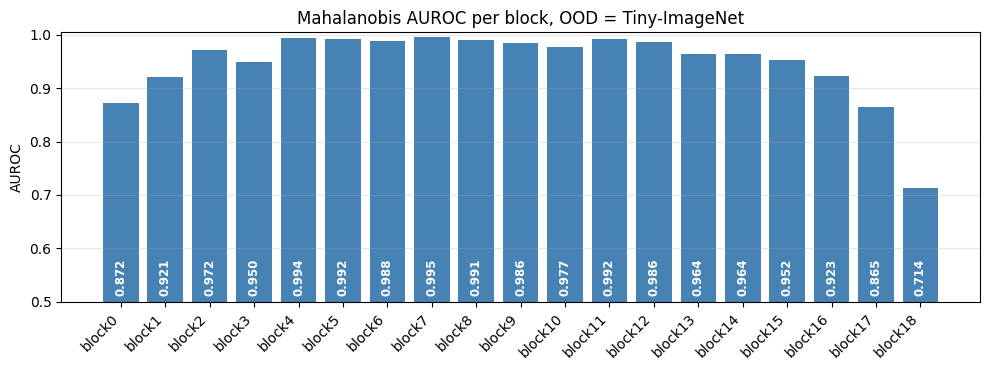

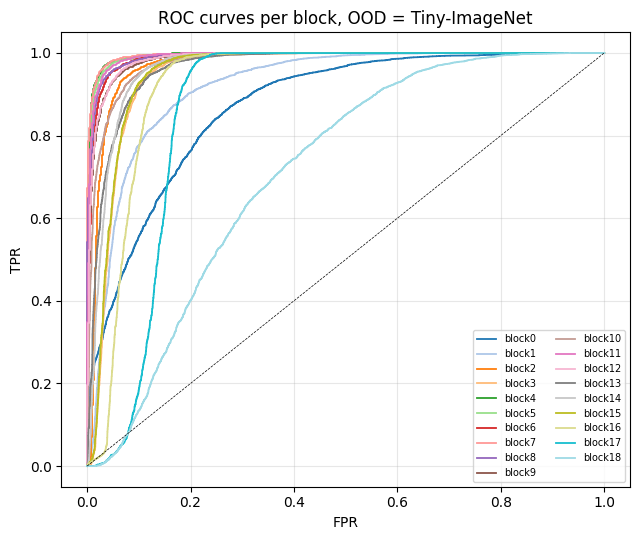

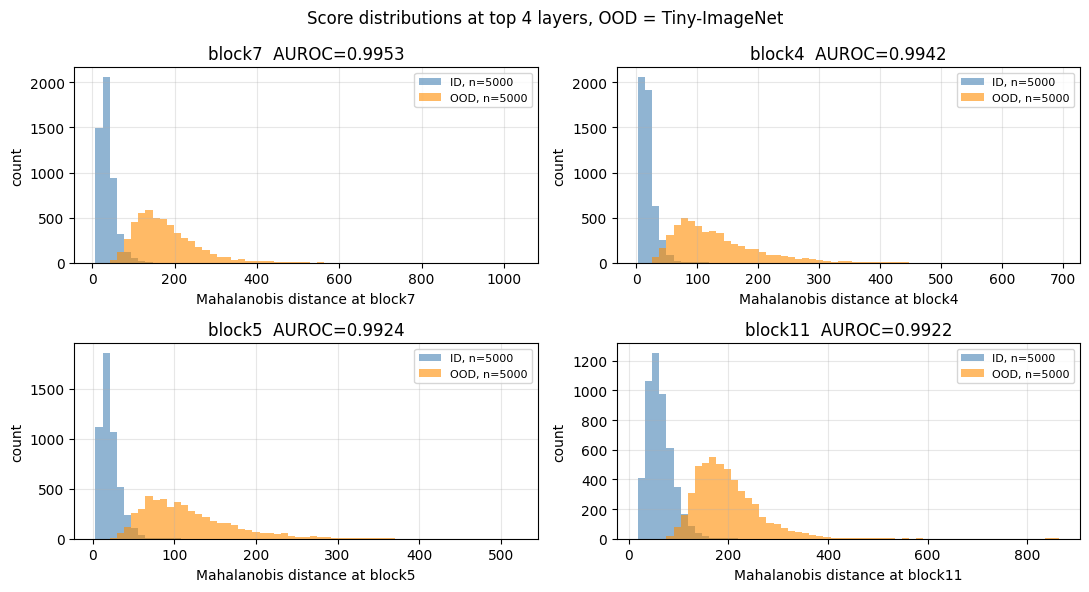

In [46]:
class TinyImageNetFlat(Dataset):
    """Flat reader for Tiny-ImageNet's `train/<wnid>/images/*.JPEG` layout."""
    def __init__(self, root, transform):
        paths = []
        for wnid in sorted(os.listdir(root)):
            d = os.path.join(root, wnid, "images")
            if not os.path.isdir(d): continue
            for f in sorted(os.listdir(d)):
                if f.lower().endswith(".jpeg"):
                    paths.append(os.path.join(d, f))
        self.paths = paths
        self.transform = transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        return self.transform(Image.open(self.paths[i]).convert("RGB")), 0


def download_tiny_imagenet():
    target = os.path.join(DATA_DIR, "tiny-imagenet-200")
    if os.path.isdir(target):
        return target
    zip_path = os.path.join(DATA_DIR, "tiny-imagenet-200.zip")
    if not os.path.exists(zip_path):
        url = "http://cs231n.stanford.edu/tiny-imagenet-200.zip"
        print(f"downloading {url} ...")
        urllib.request.urlretrieve(url, zip_path)
    print("unzipping ...")
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(DATA_DIR)
    return target


tin_base = TinyImageNetFlat(os.path.join(download_tiny_imagenet(), "train"), transform=eval_tf)
tin_ds = OODWrapper(tin_base, n=N_OOD_TEST, seed=0)
print(f"Tiny-ImageNet: {len(tin_ds)} images")

tin_result = analyze_ood_source(tin_ds, "tiny_imagenet", "Tiny-ImageNet")

### Oxford-IIIT Pet

100%|██████████| 791918971/791918971 [00:42<00:00, 18598966.33it/s]


Extracting data\oxford-iiit-pet\images.tar.gz to data\oxford-iiit-pet


100%|██████████| 19173078/19173078 [00:00<00:00, 23403974.41it/s]


Extracting data\oxford-iiit-pet\annotations.tar.gz to data\oxford-iiit-pet
Oxford Pets: 3680 images
  extract ood_test_oxford_pets (3680 samples)
  done in 209.0s
layer         AUROC   TNR@95   DetAcc
block0      0.9114   0.5329   0.8293
block1      0.9849   0.9462   0.9493
block2      0.9968   0.9986   0.9866
block3      0.9918   0.9959   0.9772
block4      0.9978   0.9957   0.9804
block5      0.9947   0.9848   0.9692
block6      0.9900   0.9677   0.9602
block7      0.9979   0.9946   0.9782
block8      0.9937   0.9766   0.9635
block9      0.9868   0.9348   0.9470
block10     0.9771   0.8677   0.9277
block11     0.9900   0.9535   0.9526
block12     0.9775   0.8524   0.9267
block13     0.9530   0.6965   0.8932
block14     0.9574   0.6978   0.9147
block15     0.9474   0.5861   0.9145
block16     0.9238   0.2288   0.9090
block17     0.8591   0.0052   0.8868
block18     0.7363   0.0139   0.7114

best single layer: block7  AUROC=0.9979


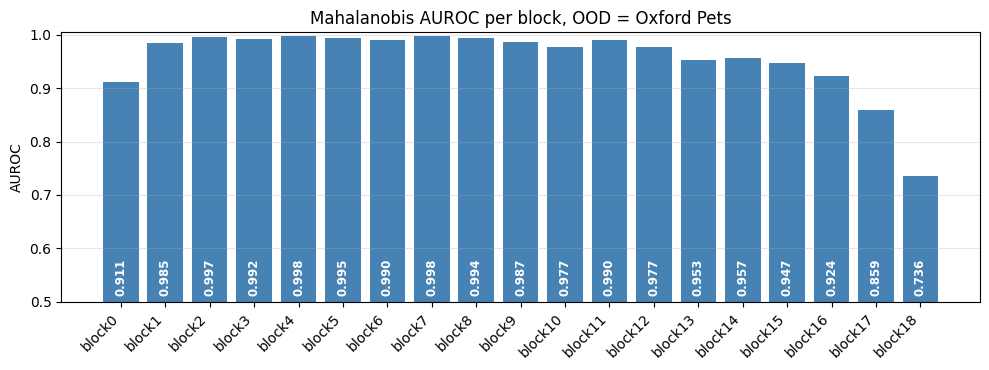

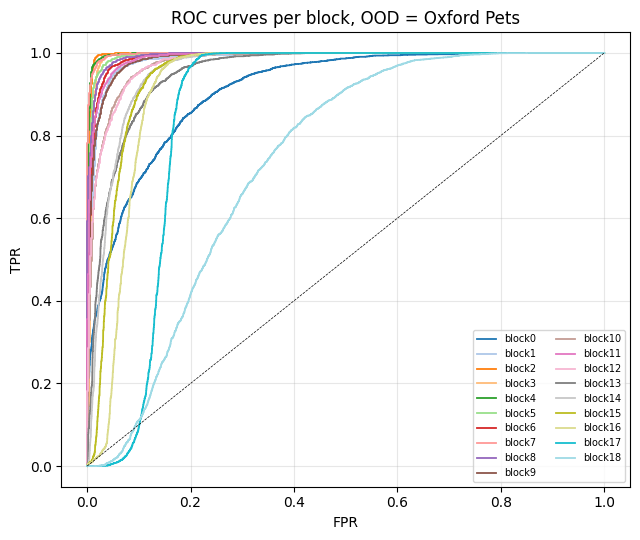

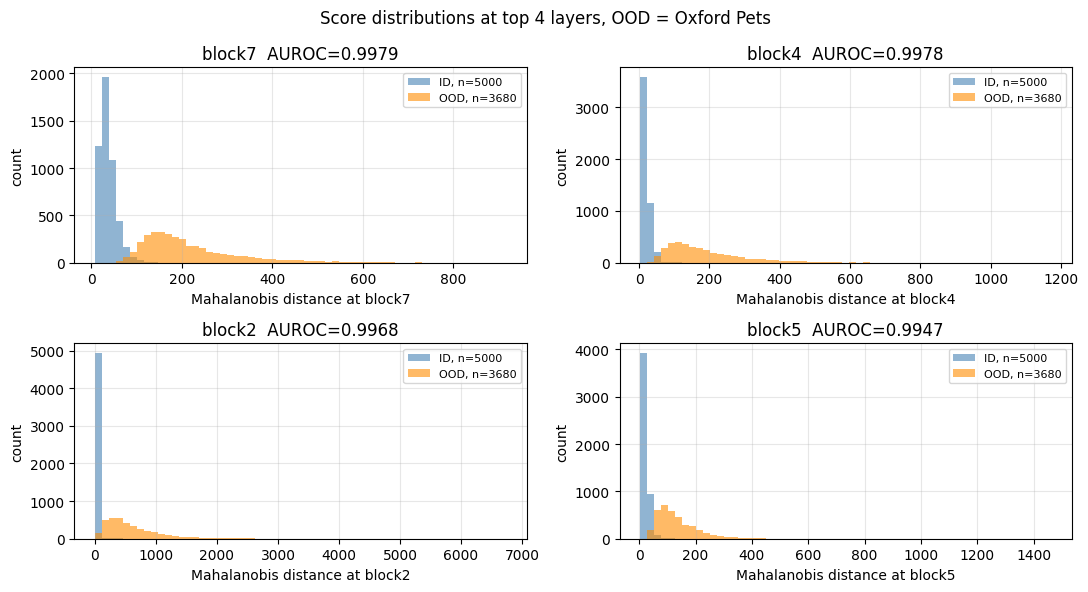

In [47]:
from torchvision.datasets import OxfordIIITPet

pets_base = OxfordIIITPet(root=DATA_DIR, split="trainval", target_types="category",
                          transform=eval_tf, download=True)
pets_ds = OODWrapper(pets_base, n=N_OOD_TEST, seed=0)
print(f"Oxford Pets: {len(pets_ds)} images")

pets_result = analyze_ood_source(pets_ds, "oxford_pets", "Oxford Pets")